Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TF Version: 2.19.0
Found 4172 files belonging to 7 classes.
Found 894 files belonging to 7 classes.
Found 897 files belonging to 7 classes.
Classes: ['Calculus', 'Caries', 'Gingivitis', 'Healthy_Teeth', 'Hypodontia', 'Mouth_Ulcer', 'Tooth_Discoloration']
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,178,806 (42.64 MB)

 Trainable params: 395,271 (1.51 MB)

 Non-trainable params: 10,783,535 (41.14 MB)

Epoch 1/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 795s 6s/step - accuracy: 0.5442 - loss: 1.2327 - val_accuracy: 0.7315 - val_loss: 0.6963
Epoch 2/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 34s 259ms/step - accuracy: 0.6933 - loss: 0.7688 - val_accuracy: 0.7416 - val_loss: 0.6547
Epoch 3/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 34s 258ms/step - accuracy: 0.7289 - loss: 0.6773 - val_accuracy: 0.7338 - val_loss: 0.6167
Epoch 4/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 34s 257ms/step - accuracy: 0.7317 - loss: 0.6658 - val_accuracy: 0.7528 - val_loss: 0.5726
Epoch 5/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 34s 258ms/step - accuracy: 0.7477 - loss: 0.6129 - val_accuracy: 0.7696 - val_loss: 0.5676
Epoch 6/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 34s 256ms/step - accuracy: 0.7636 - loss: 0.5975 - val_accuracy: 0.7696 - val_loss: 0.5373
Epoch 7/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 39s 294ms/step - accuracy: 0.7759 - loss: 0.5762 - val_accuracy: 0.7852 - val_loss: 0.5201
Epoch 8/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 34s 256ms/step - accuracy: 0.7839 - loss: 0.5204 - va

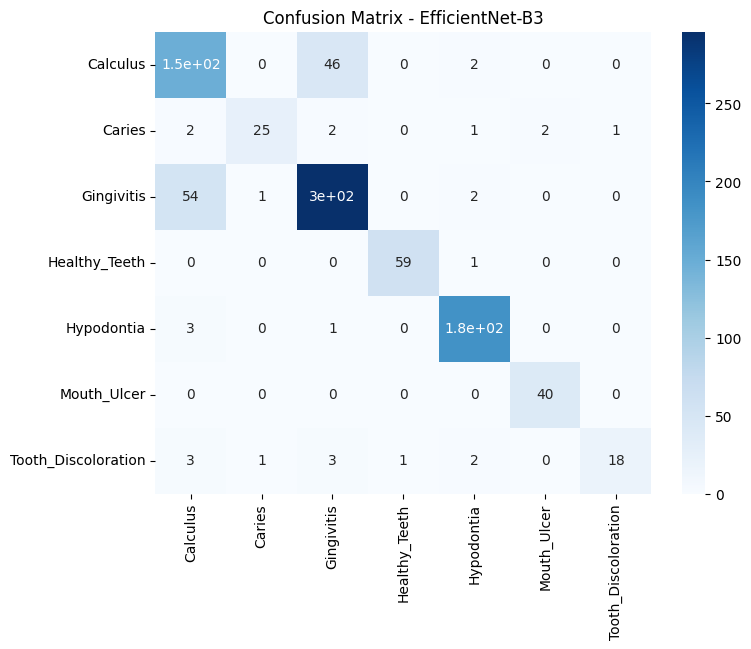


Model Saved Successfully!


In [1]:
# =============================================================
# ORAL DISEASE CLASSIFICATION - EFFICIENTNET B3
# =============================================================

from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB3
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import os

print("TF Version:", tf.__version__)

# Mixed precision (FASTER)
keras.mixed_precision.set_global_policy("mixed_float16")

# =========================== CONFIG ===========================
DATA_PATH = "/content/drive/MyDrive/prepared_data"
IMAGE_SIZE = (300, 300)        # EfficientNet-B3 recommended
BATCH_SIZE = 32
EPOCHS = 25
NUM_CLASSES = 7

# ====================== LOAD DATASETS =========================
train_ds = keras.preprocessing.image_dataset_from_directory(
    DATA_PATH + "/train",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True
)

val_ds = keras.preprocessing.image_dataset_from_directory(
    DATA_PATH + "/val",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

test_ds = keras.preprocessing.image_dataset_from_directory(
    DATA_PATH + "/test",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

CLASS_NAMES = train_ds.class_names
print("Classes:", CLASS_NAMES)

# Pipeline boost
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

# ======================= DATA AUGMENTATION =====================
data_aug = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])

# ======================= BASE MODEL ============================
base = EfficientNetB3(
    weights="imagenet",
    include_top=False,
    input_shape=IMAGE_SIZE + (3,)
)

base.trainable = False     # First train only the head

# ======================= BUILD MODEL ============================
inputs = layers.Input(shape=IMAGE_SIZE + (3,))
x = data_aug(inputs)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax", dtype='float32')(x)

model = keras.Model(inputs, outputs)
model.summary()

# ======================== COMPILE ===============================
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ==================== TRAIN HEAD LAYERS =========================
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    verbose=1
)

# ===================== FINE-TUNE BASE MODEL =====================
base.trainable = True
for layer in base.layers[:-100]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

fine_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    verbose=1,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(factor=0.2, patience=2)
    ]
)

# ====================== EVALUATE ================================
print("\nTEST RESULTS")
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)

# ================== CONFUSION MATRIX ============================
y_true = []
y_pred = []

for images, labels in test_ds:
    probs = model.predict(images)
    y_pred.extend(np.argmax(probs, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix - EfficientNet-B3")
plt.show()

# ====================== SAVE MODEL ==============================
model.save("/content/drive/MyDrive/oral_efficientnet_b3_V2.keras")
print("\nModel Saved Successfully!")
